# Exploratory Data Analysis (EDA)

## Table of Contents
1. [Dataset Overview](#dataset-overview)
2. [Handling Missing Values](#handling-missing-values)
3. [Feature Distributions](#feature-distributions)
4. [Possible Biases](#possible-biases)
5. [Correlations](#correlations)


. [Correlations](#correlations)


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Overview

[Provide a high-level overview of the dataset. This should include the source of the dataset, the number of samples, the number of features, and example showing the structure of the dataset.]


In [2]:

import pandas as pd

# Load the data
# Replace 'your_dataset.csv' with the path to your actual dataset
df = pd.read_csv('../hanabi_dataset.csv')

# Number of samples
num_samples = df.shape[0]

# Number of features
num_features = df.shape[1]

# Display these dataset characteristics
print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features}")

# Display the first few rows of the dataframe to show the structure
print("Example data:")
print(df.head())


Number of samples: 2040
Number of features: 52
Example data:
                file_source  final_score  p1_green1  p1_green2  p1_green3  \
0  game003d9bcb9d27dacf.log           15          1          0          0   
1  game0073425f0b25520f.log           17          1          0          0   
2  game007c0324e3f7b88a.log           19          0          0          0   
3  game007e20cb959b48fa.log           12          1          1          0   
4  game00abb0a354af727f.log            9          0          1          1   

   p1_green4  p1_green5  p1_yellow1  p1_yellow2  p1_yellow3  ...  p2_blue1  \
0          0          0           1           1           0  ...         0   
1          0          0           0           0           0  ...         0   
2          2          0           1           0           0  ...         0   
3          0          0           0           0           0  ...         2   
4          0          0           0           0           0  ...         1   

   p2_b

## Handling Missing Values

[Identify any missing values in the dataset, and describe your approach to handle them if there are any. If there are no missing values simply indicate that there are none.]


In [63]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values


file_source    0
final_score    0
p1_green1      0
p1_green2      0
p1_green3      0
p1_green4      0
p1_green5      0
p1_yellow1     0
p1_yellow2     0
p1_yellow3     0
p1_yellow4     0
p1_yellow5     0
p1_white1      0
p1_white2      0
p1_white3      0
p1_white4      0
p1_white5      0
p1_blue1       0
p1_blue2       0
p1_blue3       0
p1_blue4       0
p1_blue5       0
p1_red1        0
p1_red2        0
p1_red3        0
p1_red4        0
p1_red5        0
p2_green1      0
p2_green2      0
p2_green3      0
p2_green4      0
p2_green5      0
p2_yellow1     0
p2_yellow2     0
p2_yellow3     0
p2_yellow4     0
p2_yellow5     0
p2_white1      0
p2_white2      0
p2_white3      0
p2_white4      0
p2_white5      0
p2_blue1       0
p2_blue2       0
p2_blue3       0
p2_blue4       0
p2_blue5       0
p2_red1        0
p2_red2        0
p2_red3        0
p2_red4        0
p2_red5        0
dtype: int64

In [ ]:
# Handling missing values
# Example: Replacing NaN values with the mean value of the column
# df.fillna(df.mean(), inplace=True)

# Your code for handling missing values goes here


## Feature Distributions

[Plot the distribution of various features and target variables. Comment on the skewness, outliers, or any other observations.]


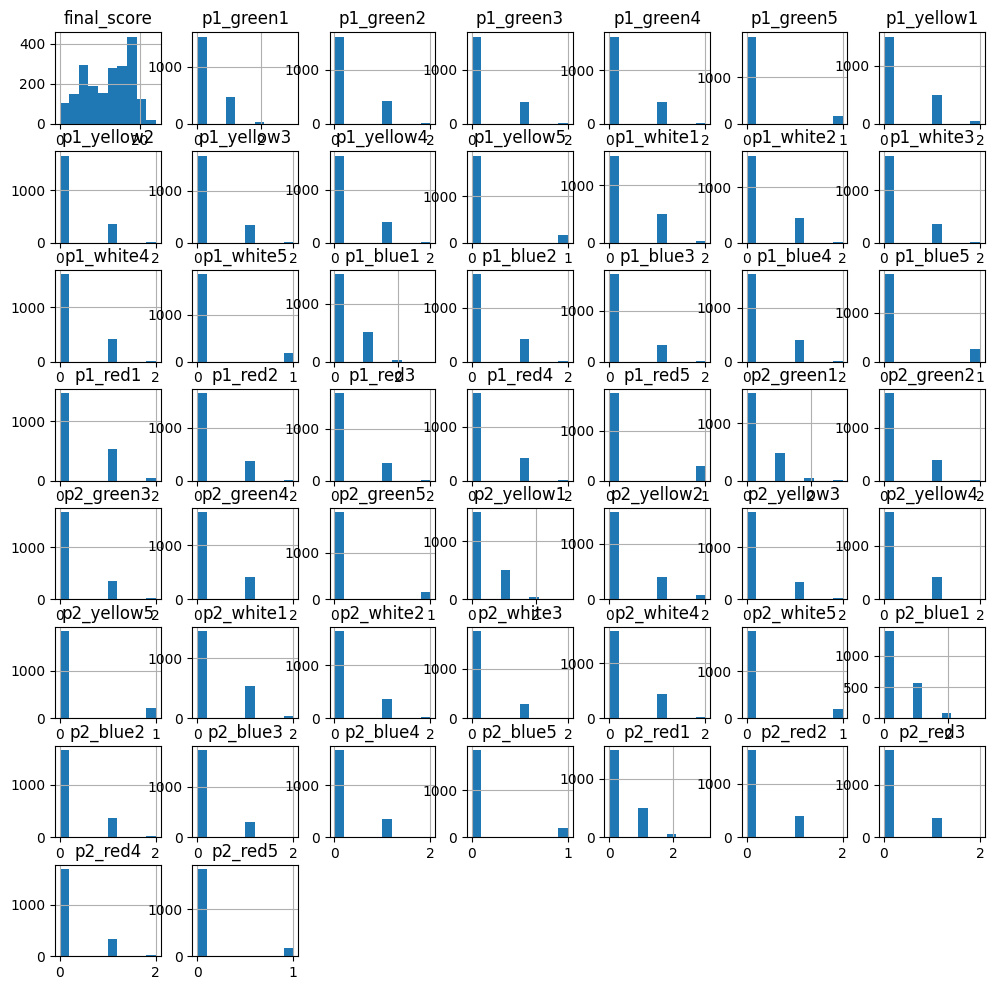

In [64]:
# Example: Plotting histograms of all numerical features
df.hist(figsize=(12, 12))
plt.show()


## Possible Biases

[Investigate the dataset for any biases that could affect the model’s performance and fairness (e.g., class imbalance, historical biases).]

### Scores
The target variable (final score) is imbalanced. Most games achieve scores between 15 and 20, while very high scores above 22 are rare and the maximum possible score of 25 does not occur at all. Since the game is cooperative, successful games are likely overrepresented in the dataset.  
This imbalance may bias the model toward predicting medium-to-high scores and reduce prediction quality for rare outcomes, especially near-perfect games.

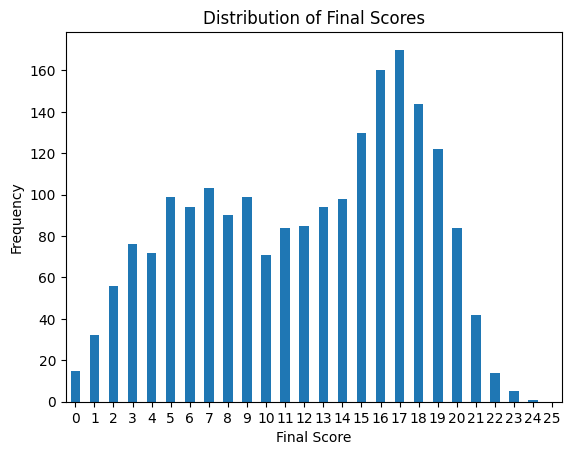

In [49]:
score_counts = df["final_score"].value_counts().sort_index().reindex(range(26),fill_value=0)
score_counts.plot(kind="bar")
plt.xlabel("Final Score")
plt.ylabel("Frequency")
plt.title("Distribution of Final Scores")
plt.xticks(rotation=0)
plt.show()

### Starting state
The dataset likely suffers from sampling bias because the number of possible card distributions in the game is extremely large compared to the available 2040 samples. Analysis of repeated game states shows that some starting configurations occur multiple times, while many possible states are never observed. Therefore, the dataset may not fully represent the complete space of valid game situations.

Number of duplicate states: 389
Unique states: 1651
Total samples: 2040


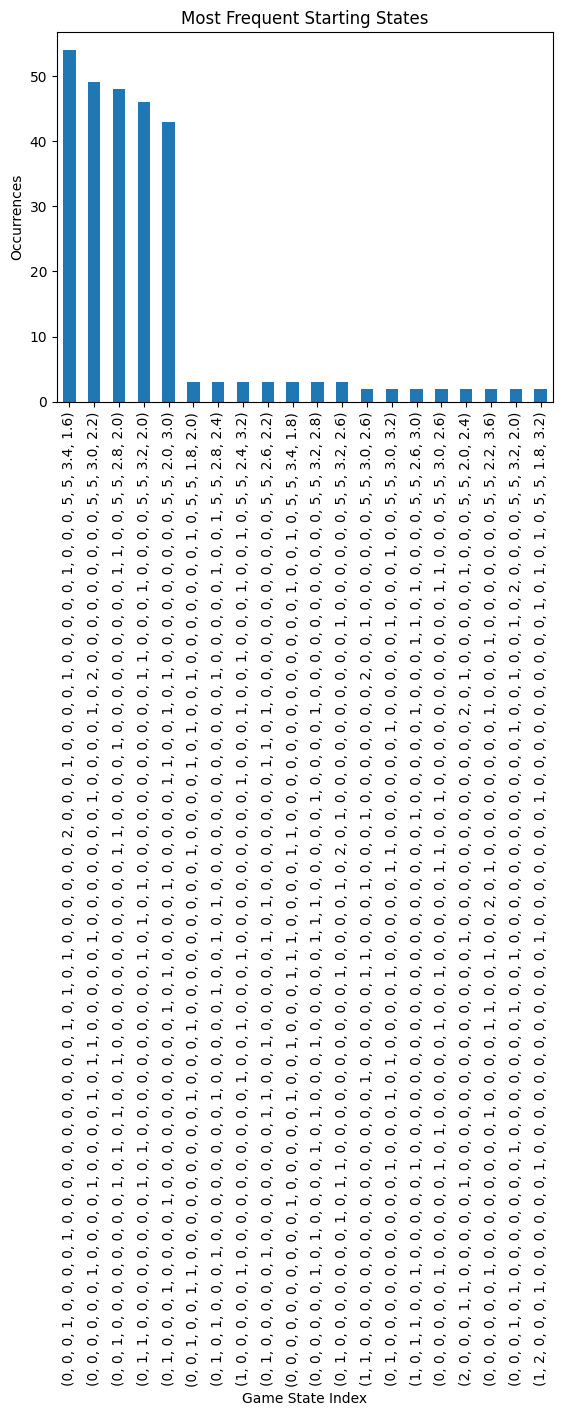

In [50]:
feature_cols = [c for c in df.columns if c not in ["file_source", "final_score"]]

duplicate_count = df.duplicated(subset=feature_cols).sum()

print("Number of duplicate states:", duplicate_count)

unique_states = df[feature_cols].drop_duplicates().shape[0]

print("Unique states:", unique_states)
print("Total samples:", len(df))

state_frequencies = (
    df[feature_cols]
    .value_counts()
    .sort_values(ascending=False)
)

state_frequencies.head(20).plot(kind="bar")

plt.xlabel("Game State Index")
plt.ylabel("Occurrences")
plt.title("Most Frequent Starting States")

plt.show()

The dataset contains a small number of starting states that occur disproportionately often compared to the majority of states. While most configurations appear only a few times, several states occur around 45 times. This suggests a sampling concentration bias, where certain game situations are heavily overrepresented.
Such repetition may bias the model toward memorizing common states instead of learning generalizable patterns. Additionally, if duplicate states appear in both training and test data, evaluation metrics may become overly optimistic.  
Methods to assure proper training of the data based on this dataset coud be to remove highly duplicated starting sets, make sure the highly duplicated sets are all in either training or test data set or to add weighs to reduce the importance of repeated states.

### Player Symmetry
The game logs represent games played by a human player (p2) against an AI player (p1). The differentiation between player 1 and player2 should have no impact on the outcom distribution but the structure of the dataset could introduce a bias towards a player. Since the game is cooperative and symmetric, systematic differences between Player 1 and Player 2 distributions could introduce positional bias into the model.  

The dataset may also contain historical strategy bias because recorded games reflect the decisions and play styles of the original players. If certain strategies dominate the logs, the model may generalize poorly to alternative approaches.

In [51]:
p1_cols = [c for c in df.columns if c.startswith("p1_") and c[-1].isdigit()]
p2_cols = [c for c in df.columns if c.startswith("p2_") and c[-1].isdigit()]

df["p1_total_cards"] = df[p1_cols].sum(axis=1)
df["p2_total_cards"] = df[p2_cols].sum(axis=1)

print(df[["p1_total_cards", "p2_total_cards"]].describe())

# check average card values per player
# helper function to extract card value from column name
def extract_value(col):
    return int(col[-1])

# weighted average card value
p1_value_sum = sum(df[col] * extract_value(col) for col in p1_cols)
p2_value_sum = sum(df[col] * extract_value(col) for col in p2_cols)

df["p1_avg_value"] = p1_value_sum / 5
df["p2_avg_value"] = p2_value_sum / 5

print(df[["p1_avg_value", "p2_avg_value"]].describe())

       p1_total_cards  p2_total_cards
count          2040.0          2040.0
mean              5.0             5.0
std               0.0             0.0
min               5.0             5.0
25%               5.0             5.0
50%               5.0             5.0
75%               5.0             5.0
max               5.0             5.0
       p1_avg_value  p2_avg_value
count   2040.000000   2040.000000
mean       2.644510      2.559510
std        0.579204      0.592803
min        1.000000      1.000000
25%        2.200000      2.200000
50%        2.600000      2.600000
75%        3.000000      3.000000
max        4.600000      4.400000


Both players always have the same amount of cards in every game. The small differences in mean and maximum values are minor and likely due to random variation rather than a structural imbalance.


### Cards
Due to random sampling of starting hands and the low number of samples in this dataset, it is possible that some cards may be over- or underrepresented. The card distirbution in the game itself is not equally distributed: There are a total of 50 cards in 5 colors: red, yellow, green, blue and white, and with 10 cards per color. For each color, there is 3x the number 1, 2x the numbers 2, 3 and 4 and only once the number 5. 
If the distribution of cards does not align with the distribution of cards in the game, a bias towards specific cards/ colors or numbers coul be introduced.

          P1_Mean   P2_Mean      Diff
blue1    0.278431  0.361765  0.083333
yellow2  0.192647  0.269118  0.076471
red5     0.144118  0.088725  0.055392
white3   0.188725  0.148529  0.040196
red4     0.217157  0.179902  0.037255
white1   0.275490  0.311765  0.036275
blue5    0.128431  0.094118  0.034314
white2   0.237745  0.206373  0.031373
blue4    0.212255  0.183333  0.028922
green2   0.221078  0.197059  0.024020
green3   0.211765  0.189706  0.022059
yellow5  0.084804  0.105882  0.021078
white4   0.222549  0.236275  0.013725
red3     0.181373  0.194608  0.013235
blue2    0.212255  0.200000  0.012255
yellow4  0.198039  0.209804  0.011765
green4   0.208824  0.220098  0.011275
green1   0.268627  0.278922  0.010294
blue3    0.169608  0.159804  0.009804
red2     0.200000  0.208333  0.008333
white5   0.088235  0.094608  0.006373
yellow3  0.185784  0.188235  0.002451
green5   0.081373  0.083333  0.001961
red1     0.300980  0.299510  0.001471
yellow1  0.289706  0.290196  0.000490


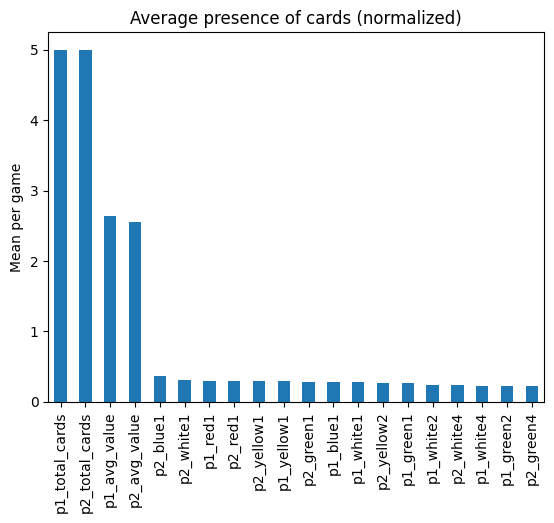

In [57]:
# Compare the mean number of cards held by each position
comparison = pd.DataFrame({
    'P1_Mean': df[p1_cols].mean().values,
    'P2_Mean': df[p2_cols].mean().values
}, index=[c.replace('p1_', '') for c in p1_cols])

comparison['Diff'] = (comparison['P1_Mean'] - comparison['P2_Mean']).abs()
print(comparison.sort_values(by='Diff', ascending=False))

card_cols = [c for c in df.columns if c not in ["file_source", "final_score"]]

# Overall card frequency
card_freq_norm = df[card_cols].mean().sort_values(ascending=False)

card_freq_norm.head(20).plot(kind="bar")
plt.title("Average presence of cards (normalized)")
plt.ylabel("Mean per game")
plt.xticks(rotation=90)
plt.show()

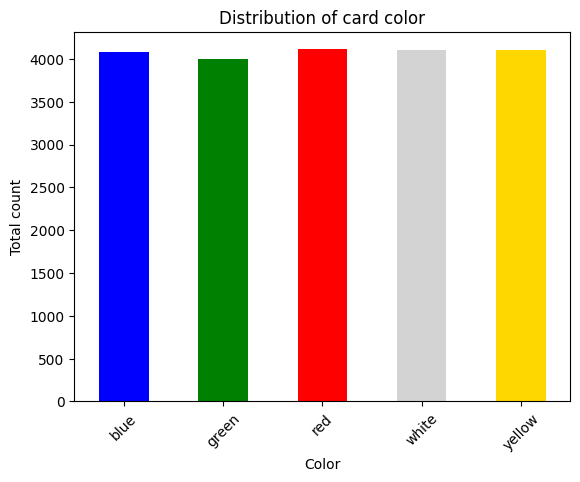

In [55]:
# Create a df without player info and without score
p1 = df.filter(p1_cols).copy()
p1.columns = p1.columns.str.replace('p1_', '', regex=False)
p2 = df.filter(p2_cols).copy()
p2.columns = p2.columns.str.replace('p2_', '', regex=False)

card_df = pd.concat([p1,p2], ignore_index=True)
column_sums = card_df.sum()

column_sums = column_sums.reset_index()
column_sums.columns = ["card", "count"]
column_sums["color"] = column_sums["card"].str.extract(r'([a-zA-Z]+)')
column_sums["number"] = column_sums["card"].str.extract(r'([0-9]+)')

# Distribution by card color
color_totals = column_sums.groupby("color")["count"].sum()
colors = ["blue", "green", "red", "lightgray", "gold"]
color_totals.plot(kind="bar", color=colors)
plt.xlabel("Color")
plt.ylabel("Total count")
plt.title("Distribution of card color")
plt.xticks(rotation=45)
plt.show()

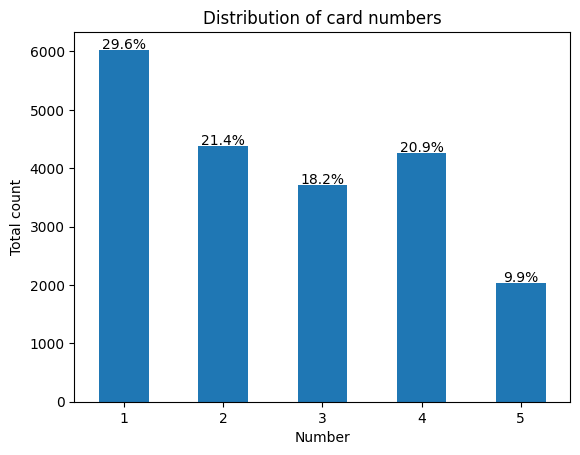

In [56]:
# Differences by number
number_totals = column_sums.groupby("number")["count"].sum()
number_freq = (number_totals / number_totals.sum() * 100).round(1)


ax = number_totals.plot(kind="bar")

for i, value in enumerate(number_totals):
    pct = number_freq.iloc[i]
    ax.text(
        i,
        value + 20,
        f"{pct}%",
        ha="center"
    )

plt.xlabel("Number")
plt.ylabel("Total count")
plt.title("Distribution of card numbers")
plt.xticks(rotation=0)
plt.show()

The distribution of cards amongst players and by color is uniform. Only the distribution by card number differs slightly from the expected values. Overall, the pattern remains as expected, with number 1 cards being the most frequent and number 5 cards being the least frequent. These small deviations from the expected frequencies are minimal and are unlikely to introduce any meaningful bias toward specific card numbers in the model.

## Correlations

[Explore correlations between features and the target variable, as well as among features themselves.]


In [60]:
# Example: Plotting a heatmap to show feature correlations
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True)
plt.show()


ValueError: could not convert string to float: 'game003d9bcb9d27dacf.log'